# Frequency Weighting Impact Analysis

This notebook investigates why frequency weighting causes such a large difference in F1 scores for the Varied Explainers experiments. Without frequency weighting, there is nearly no difference in scores between models, but with frequency weighting, significant differences emerge.

## Research Questions:
1. **What is the correlation between firing rate and F1 score impact?**
2. **Are high-frequency latents easier or harder to explain?**
3. **Do different models show different patterns in their performance on high vs low frequency latents?**
4. **What is the distribution of firing rates and how does it affect the weighted average?**

## 1. Setup and Data Loading

In [1]:
import sys
import os
import json
from pathlib import Path
import pandas as pd
import numpy as np
import torch
from scipy import stats
from scipy.stats import spearmanr, pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

# Add the parent directory to the path to import delphi modules
sys.path.append(str(Path.cwd().parent))

from delphi.log.result_analysis import (
    load_data,
    get_agg_metrics,
    add_latent_f1,
    compute_confusion,
    compute_classification_metrics,
    frequency_weighted_f1
)

# Configuration
# Point to the "500 Latents Qwen32B Scorer" directory which contains the varied explainer results
results_dir = Path.cwd().parent / "results" / "pythiaST" / "500 Latents Qwen32B Scorer"

# Create visualizations directory
visualizations_dir = Path("visualizations_dir")
visualizations_dir.mkdir(exist_ok=True, parents=True)

# Model name mapping for prettier display
MODEL_NAME_MAPPING = {
    "gemma_3_4b_it_quantized_w4a16": "Gemma3-4B",
    "Qwen3_4B_quantized_w4a16": "Qwen3-4B", 
    "gemma_3_12b_it_quantized_w4a16": "Gemma3-12B",
    "gemma_3_27b_it_quantized_w4a16": "Gemma3-27B",
    "Qwen3_14B_quantized_w4a16": "Qwen3-14B",
    "Qwen3_32B_quantized_w4a16": "Qwen3-32B",
    "Qwen3_235B_A22B_GPTQ_Int4": "Qwen3-235B",
    "Llama_3_3_70B_Instruct_quantized_w4a16": "Llama3.3-70B",
    "Llama_3_1_70B_Instruct_NVFP4": "Llama3.1-70B",
    "Llama_4_Scout_17B_16E_Instruct_quantized_w4a16": "Llama4-Scout",
    "Llama_4_Maverick_17B_128E_Instruct_quantized_w4a16": "Llama4-Maverick",
    "llama_8b_explainer": "Llama3-8B (Transluce)",
    "Meta_Llama_3_1_8B_Instruct_GPTQ_INT4": "Llama3-8B",
    "gpt_oss_20b": "GPT-OSS-20B"
}

# Styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print(f"Results directory: {results_dir}")
print(f"Visualizations directory: {visualizations_dir}")
print(f"Directory exists: {results_dir.exists()}")
if results_dir.exists():
    subdirs = [d.name for d in results_dir.iterdir() if d.is_dir() and d.name.startswith("pythiaST_")]
    print(f"Found {len(subdirs)} model directories")
    if subdirs:
        print(f"First few: {', '.join(subdirs[:3])}")


Results directory: /home/jeremias/projects/delphi-explanations/results/pythiaST/500 Latents Qwen32B Scorer
Visualizations directory: visualizations_dir
Directory exists: True
Found 9 model directories
First few: pythiaST_gemma_3_4b_it_quantized_w4a16_random_baseline_quantiles, pythiaST_Qwen3_4B_quantized_w4a16_random_baseline_quantiles, pythiaST_gemma_3_12b_it_quantized_w4a16_random_baseline_quantiles


## 2. Load All Model Results

In [2]:
def load_varied_explainers_results(results_dir: Path, model_mapping: dict):
    """Load results from model directories with pythiaST_<model>_random_baseline_quantiles structure."""
    model_results = {}
    model_stats = {}
    
    if not results_dir.exists():
        print(f"Warning: Directory not found: {results_dir}")
        return model_results, model_stats
    
    # Look for directories matching the pattern pythiaST_*_random_baseline_quantiles
    for model_dir in sorted(results_dir.iterdir()):
        if not model_dir.is_dir():
            continue
        
        # Check if this is a model results directory
        if not model_dir.name.startswith("pythiaST_"):
            continue
        
        # Extract model name from directory name
        # Format: pythiaST_<model_name>_random_baseline_quantiles
        dir_name = model_dir.name
        
        # Remove prefix and suffix
        if "_random_baseline_quantiles" in dir_name:
            model_key = dir_name.replace("pythiaST_", "").replace("_random_baseline_quantiles", "")
        else:
            # Fallback: just remove pythiaST_ prefix
            parts = dir_name.replace("pythiaST_", "").split("_random_")
            if len(parts) >= 1:
                model_key = parts[0]
            else:
                continue
        
        display_name = model_mapping.get(model_key, model_key)
        
        # Check if cached data exists (this is the fastest way)
        cache_file = model_dir / "cached_dataframe.pkl"
        scores_path = model_dir / "scores"
        
        if not scores_path.exists():
            print(f"⊗ Skipping {display_name}: missing scores directory")
            continue
        
        try:
            # Try to use cached data first (includes firing counts)
            if cache_file.exists():
                import pickle
                with open(cache_file, 'rb') as f:
                    cached_data = pickle.load(f)
                latent_df = cached_data['latent_df']
                counts = cached_data['counts']
                print(f"  Loaded from cache: {cache_file.name}")
            else:
                # Fallback: load from scores directory
                # We'll use the model_dir as latents_path since that's where load_data looks for log/
                modules = ["resid_post_layer_7"]
                latent_df, counts = load_data(scores_path, model_dir, modules, use_cache=True)
            
            # Add per-latent F1 scores
            latent_df = add_latent_f1(latent_df)
            
            # Compute aggregate metrics
            processed_df = get_agg_metrics(latent_df, counts)
            processed_df = processed_df.set_index('score_type')
            
            model_results[display_name] = {
                'latent_df': latent_df,
                'processed_df': processed_df,
                'counts': counts
            }
            
            n_latents = len(latent_df[['module', 'latent_idx']].drop_duplicates())
            n_examples = len(latent_df)
            score_types = latent_df['score_type'].unique()
            print(f"✓ Loaded {display_name}: {n_examples:,} examples, {n_latents} latents, "
                  f"score types: {', '.join(score_types)}")
            
            if counts is None:
                print(f"  ⚠ Warning: No firing counts available for {display_name}")
            
        except Exception as e:
            print(f"✗ Error loading {display_name}: {e}")
            import traceback
            traceback.print_exc()
            continue
    
    return model_results, model_stats

# Load the data
print("Loading model results from directory structure...\n")
print(f"Looking for directories matching: pythiaST_*_random_baseline_quantiles\n")
model_results, model_stats = load_varied_explainers_results(results_dir, MODEL_NAME_MAPPING)

print(f"\n{'='*80}")
print(f"Loaded {len(model_results)} models successfully")
if model_results:
    print("Models:", ", ".join(sorted(model_results.keys())))
else:
    print("No models loaded. Please check the results_dir path and directory structure.")
print(f"{'='*80}")

Loading model results from directory structure...

Looking for directories matching: pythiaST_*_random_baseline_quantiles

  Loaded from cache: cached_dataframe.pkl
✓ Loaded Llama3.3-70B: 375,000 examples, 375 latents, score types: fuzz, detection
  Loaded from cache: cached_dataframe.pkl
✓ Loaded Llama4-Scout: 375,000 examples, 375 latents, score types: fuzz, detection
  Loaded from cache: cached_dataframe.pkl
✓ Loaded Llama3-8B: 375,000 examples, 375 latents, score types: fuzz, detection
  Loaded from cache: cached_dataframe.pkl
✓ Loaded Qwen3-14B: 375,000 examples, 375 latents, score types: fuzz, detection
  Loaded from cache: cached_dataframe.pkl
✓ Loaded Qwen3-32B: 375,000 examples, 375 latents, score types: fuzz, detection
  Loaded from cache: cached_dataframe.pkl
✓ Loaded Qwen3-4B: 375,000 examples, 375 latents, score types: fuzz, detection
  Loaded from cache: cached_dataframe.pkl
✓ Loaded Gemma3-12B: 375,000 examples, 375 latents, score types: fuzz, detection
  Loaded from cac

## 3. Compute Both Weighted and Unweighted F1 Scores

For each model, we'll compute:
- **Unweighted F1**: Simple average of per-latent F1 scores
- **Weighted F1**: Frequency-weighted average of per-latent F1 scores
- **Impact**: Difference between weighted and unweighted scores

In [3]:
def compute_unweighted_f1(df: pd.DataFrame) -> float:
    """Compute simple unweighted F1 as mean of per-latent F1 scores."""
    rows = []
    for (module, latent_idx), grp in df.groupby(["module", "latent_idx"]):
        f1 = compute_classification_metrics(compute_confusion(grp))["f1_score"]
        rows.append({"module": module, "latent_idx": latent_idx, "f1_score": f1})
    
    if not rows:
        return 0.0
    
    latent_df = pd.DataFrame(rows)
    return latent_df["f1_score"].mean()

# Compute both metrics for each model and score type
comparison_data = []

for model_name, data in model_results.items():
    latent_df = data['latent_df']
    counts = data['counts']
    
    for score_type in latent_df['score_type'].unique():
        score_subset = latent_df[latent_df['score_type'] == score_type]
        
        # Compute unweighted F1
        unweighted_f1 = compute_unweighted_f1(score_subset)
        
        # Compute weighted F1
        weighted_f1 = frequency_weighted_f1(score_subset, counts) if counts else None
        
        if weighted_f1 is not None:
            comparison_data.append({
                'model': model_name,
                'score_type': score_type,
                'unweighted_f1': unweighted_f1,
                'weighted_f1': weighted_f1,
                'impact': weighted_f1 - unweighted_f1,
                'impact_pct': ((weighted_f1 - unweighted_f1) / unweighted_f1 * 100) if unweighted_f1 > 0 else 0
            })

comparison_df = pd.DataFrame(comparison_data)

print("\nWeighted vs Unweighted F1 Comparison:")
print("="*80)
print(comparison_df.sort_values('impact', ascending=False).to_string(index=False))

# Summary statistics
print("\n\nSummary Statistics:")
print("="*80)
print(f"Average Unweighted F1: {comparison_df['unweighted_f1'].mean():.4f}")
print(f"Average Weighted F1: {comparison_df['weighted_f1'].mean():.4f}")
print(f"Average Impact: {comparison_df['impact'].mean():.4f}")
print(f"Std Dev of Impact: {comparison_df['impact'].std():.4f}")


Weighted vs Unweighted F1 Comparison:
       model score_type  unweighted_f1  weighted_f1    impact  impact_pct
   Qwen3-14B  detection       0.708281     0.567450 -0.140831  -19.883500
   Qwen3-32B  detection       0.713237     0.555715 -0.157522  -22.085468
Llama4-Scout  detection       0.686091     0.526190 -0.159901  -23.306071
    Qwen3-4B  detection       0.710064     0.548456 -0.161608  -22.759616
Llama3.3-70B  detection       0.709512     0.543130 -0.166382  -23.450195
   Llama3-8B  detection       0.690801     0.523569 -0.167232  -24.208368
   Qwen3-32B       fuzz       0.843957     0.674856 -0.169102  -20.036751
Llama4-Scout       fuzz       0.836277     0.666691 -0.169585  -20.278619
   Qwen3-14B       fuzz       0.840337     0.669701 -0.170635  -20.305599
  Gemma3-12B  detection       0.703054     0.530279 -0.172775  -24.574968
Llama3.3-70B       fuzz       0.839120     0.662695 -0.176425  -21.025031
  Gemma3-12B       fuzz       0.831045     0.648687 -0.182359  -21.943281

## 4. Visualize Weighted vs Unweighted F1 Scores

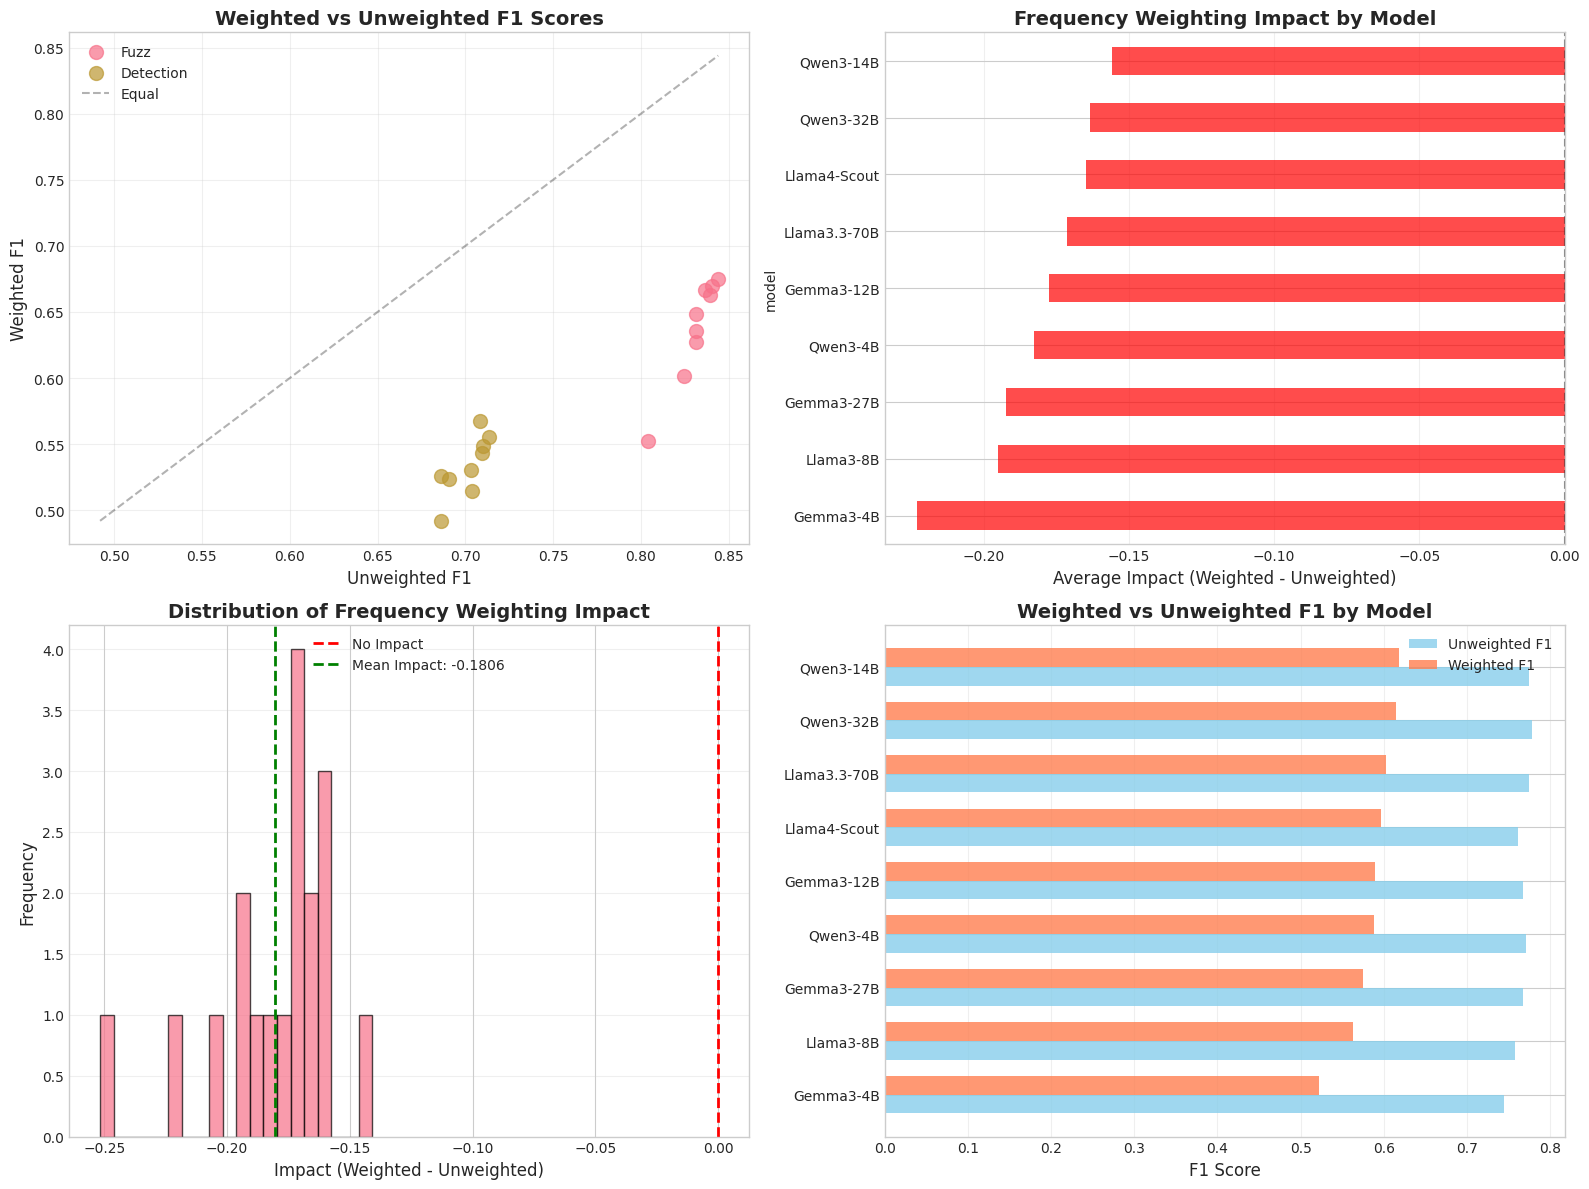


Plot saved as 'visualizations_dir/frequency_weighting_comparison.png'


In [4]:
# Create comparison plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Weighted vs Unweighted for each model (by score type)
ax1 = axes[0, 0]
for score_type in comparison_df['score_type'].unique():
    subset = comparison_df[comparison_df['score_type'] == score_type]
    ax1.scatter(subset['unweighted_f1'], subset['weighted_f1'], 
               label=score_type.capitalize(), alpha=0.7, s=100)

# Add diagonal line (where weighted = unweighted)
min_val = min(comparison_df['unweighted_f1'].min(), comparison_df['weighted_f1'].min())
max_val = max(comparison_df['unweighted_f1'].max(), comparison_df['weighted_f1'].max())
ax1.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.3, label='Equal')

ax1.set_xlabel('Unweighted F1', fontsize=12)
ax1.set_ylabel('Weighted F1', fontsize=12)
ax1.set_title('Weighted vs Unweighted F1 Scores', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Impact by model
ax2 = axes[0, 1]
model_impact = comparison_df.groupby('model')['impact'].mean().sort_values()
colors = ['red' if x < 0 else 'green' for x in model_impact.values]
model_impact.plot(kind='barh', ax=ax2, color=colors, alpha=0.7)
ax2.set_xlabel('Average Impact (Weighted - Unweighted)', fontsize=12)
ax2.set_title('Frequency Weighting Impact by Model', fontsize=14, fontweight='bold')
ax2.axvline(x=0, color='black', linestyle='--', alpha=0.5)
ax2.grid(True, alpha=0.3, axis='x')

# Plot 3: Impact distribution
ax3 = axes[1, 0]
ax3.hist(comparison_df['impact'], bins=20, edgecolor='black', alpha=0.7)
ax3.axvline(x=0, color='red', linestyle='--', linewidth=2, label='No Impact')
ax3.axvline(x=comparison_df['impact'].mean(), color='green', linestyle='--', 
           linewidth=2, label=f"Mean Impact: {comparison_df['impact'].mean():.4f}")
ax3.set_xlabel('Impact (Weighted - Unweighted)', fontsize=12)
ax3.set_ylabel('Frequency', fontsize=12)
ax3.set_title('Distribution of Frequency Weighting Impact', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Side-by-side comparison
ax4 = axes[1, 1]
x = np.arange(len(comparison_df['model'].unique()))
width = 0.35

# Aggregate by model (mean across score types)
model_agg = comparison_df.groupby('model').agg({
    'unweighted_f1': 'mean',
    'weighted_f1': 'mean'
}).sort_values('weighted_f1')

x_pos = np.arange(len(model_agg))
ax4.barh(x_pos - width/2, model_agg['unweighted_f1'], width, 
        label='Unweighted F1', alpha=0.8, color='skyblue')
ax4.barh(x_pos + width/2, model_agg['weighted_f1'], width, 
        label='Weighted F1', alpha=0.8, color='coral')

ax4.set_yticks(x_pos)
ax4.set_yticklabels(model_agg.index)
ax4.set_xlabel('F1 Score', fontsize=12)
ax4.set_title('Weighted vs Unweighted F1 by Model', fontsize=14, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(visualizations_dir / 'frequency_weighting_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nPlot saved as '{visualizations_dir / 'frequency_weighting_comparison.png'}'")

## 5. Analyze Firing Rate Distribution

Let's understand the distribution of firing rates across latents and how they affect the weighted average.

Firing Rate Statistics:
count    3.276800e+04
mean     9.759978e+03
std      4.333688e+04
min      0.000000e+00
25%      2.020000e+02
50%      1.091000e+03
75%      3.922250e+03
max      1.731517e+06
Name: firing_count, dtype: float64

Total tokens processed: 319,814,958
Number of latents: 32768

50% of total weight comes from 636 latents (1.9%)
80% of total weight comes from 2924 latents (8.9%)
95% of total weight comes from 10312 latents (31.5%)


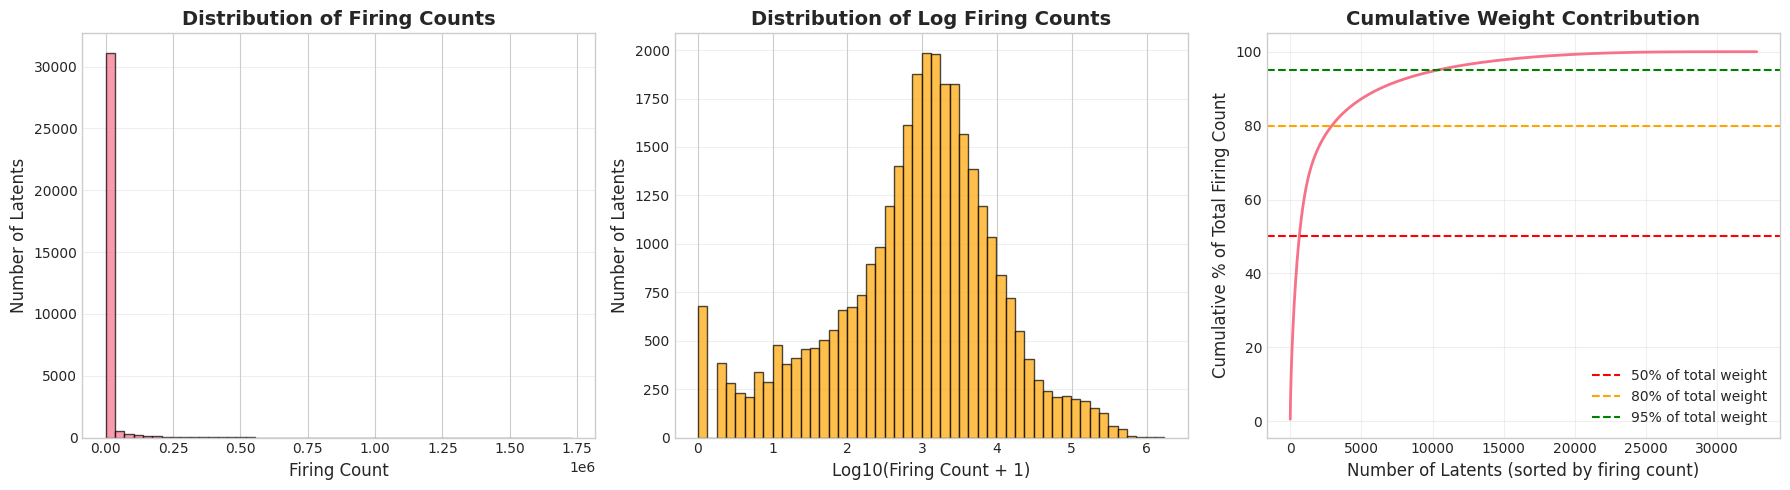


Plot saved as 'visualizations_dir/firing_rate_distribution.png'


In [5]:
# Get firing rate distribution from one model (all models use the same SAE)
first_model_name = list(model_results.keys())[0]
counts = model_results[first_model_name]['counts']
latent_df = model_results[first_model_name]['latent_df']

# Extract all firing counts
firing_data = []
for module in counts.keys():
    for latent_idx in range(len(counts[module])):
        firing_count = counts[module][latent_idx].item()
        firing_data.append({
            'module': module,
            'latent_idx': latent_idx,
            'firing_count': firing_count
        })

firing_df = pd.DataFrame(firing_data)

print("Firing Rate Statistics:")
print("="*80)
print(firing_df['firing_count'].describe())
print(f"\nTotal tokens processed: {firing_df['firing_count'].sum():,.0f}")
print(f"Number of latents: {len(firing_df)}")

# Visualize firing rate distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Histogram of firing counts
ax1 = axes[0]
ax1.hist(firing_df['firing_count'], bins=50, edgecolor='black', alpha=0.7)
ax1.set_xlabel('Firing Count', fontsize=12)
ax1.set_ylabel('Number of Latents', fontsize=12)
ax1.set_title('Distribution of Firing Counts', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Log-scale histogram
ax2 = axes[1]
ax2.hist(np.log10(firing_df['firing_count'] + 1), bins=50, edgecolor='black', alpha=0.7, color='orange')
ax2.set_xlabel('Log10(Firing Count + 1)', fontsize=12)
ax2.set_ylabel('Number of Latents', fontsize=12)
ax2.set_title('Distribution of Log Firing Counts', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: Cumulative contribution to total weight
ax3 = axes[2]
sorted_counts = firing_df['firing_count'].sort_values(ascending=False).values
cumsum = np.cumsum(sorted_counts)
cumsum_pct = cumsum / cumsum[-1] * 100
ax3.plot(np.arange(len(cumsum_pct)), cumsum_pct, linewidth=2)
ax3.axhline(y=50, color='red', linestyle='--', label='50% of total weight')
ax3.axhline(y=80, color='orange', linestyle='--', label='80% of total weight')
ax3.axhline(y=95, color='green', linestyle='--', label='95% of total weight')
ax3.set_xlabel('Number of Latents (sorted by firing count)', fontsize=12)
ax3.set_ylabel('Cumulative % of Total Firing Count', fontsize=12)
ax3.set_title('Cumulative Weight Contribution', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Find how many latents contribute to 50%, 80%, 95%
n_50 = np.argmax(cumsum_pct >= 50)
n_80 = np.argmax(cumsum_pct >= 80)
n_95 = np.argmax(cumsum_pct >= 95)
print(f"\n50% of total weight comes from {n_50} latents ({n_50/len(firing_df)*100:.1f}%)")
print(f"80% of total weight comes from {n_80} latents ({n_80/len(firing_df)*100:.1f}%)")
print(f"95% of total weight comes from {n_95} latents ({n_95/len(firing_df)*100:.1f}%)")

plt.tight_layout()
plt.savefig(visualizations_dir / 'firing_rate_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nPlot saved as '{visualizations_dir / 'firing_rate_distribution.png'}'")

## 6. Correlation Between Firing Rate and F1 Score

Investigate whether high-frequency latents are easier or harder to explain correctly.

In [6]:
# For each model, compute per-latent F1 and analyze correlation with firing rate
correlation_results = []

for model_name, data in model_results.items():
    latent_df = data['latent_df']
    counts = data['counts']
    
    for score_type in latent_df['score_type'].unique():
        score_subset = latent_df[latent_df['score_type'] == score_type]
        
        # Compute per-latent F1 with firing rates
        per_latent_data = []
        for (module, latent_idx), grp in score_subset.groupby(["module", "latent_idx"]):
            if module in counts and latent_idx < len(counts[module]):
                f1 = compute_classification_metrics(compute_confusion(grp))["f1_score"]
                firing_count = counts[module][latent_idx].item()
                per_latent_data.append({
                    'module': module,
                    'latent_idx': latent_idx,
                    'f1_score': f1,
                    'firing_count': firing_count,
                    'log_firing_count': np.log10(firing_count + 1)
                })
        
        if len(per_latent_data) > 0:
            per_latent_df = pd.DataFrame(per_latent_data)
            
            # Compute correlations
            pearson_r, pearson_p = pearsonr(per_latent_df['firing_count'], per_latent_df['f1_score'])
            spearman_r, spearman_p = spearmanr(per_latent_df['firing_count'], per_latent_df['f1_score'])
            log_pearson_r, log_pearson_p = pearsonr(per_latent_df['log_firing_count'], per_latent_df['f1_score'])
            
            correlation_results.append({
                'model': model_name,
                'score_type': score_type,
                'pearson_r': pearson_r,
                'pearson_p': pearson_p,
                'spearman_r': spearman_r,
                'spearman_p': spearman_p,
                'log_pearson_r': log_pearson_r,
                'log_pearson_p': log_pearson_p,
                'n_latents': len(per_latent_df)
            })
            
            # Store for later plotting
            data[f'per_latent_df_{score_type}'] = per_latent_df

correlation_df = pd.DataFrame(correlation_results)

print("\nCorrelation Between Firing Rate and F1 Score:")
print("="*80)
print(correlation_df[['model', 'score_type', 'pearson_r', 'spearman_r', 'log_pearson_r']].to_string(index=False))

print("\n\nAverage Correlations:")
print("="*80)
print(f"Average Pearson r: {correlation_df['pearson_r'].mean():.4f}")
print(f"Average Spearman r: {correlation_df['spearman_r'].mean():.4f}")
print(f"Average Log-Pearson r: {correlation_df['log_pearson_r'].mean():.4f}")

# Interpretation
avg_corr = correlation_df['spearman_r'].mean()
if avg_corr > 0.3:
    print("\n⚠️  High-frequency latents tend to have HIGHER F1 scores (easier to explain)")
elif avg_corr < -0.3:
    print("\n⚠️  High-frequency latents tend to have LOWER F1 scores (harder to explain)")
else:
    print("\n✓ No strong correlation between firing rate and F1 score")


Correlation Between Firing Rate and F1 Score:
       model score_type  pearson_r  spearman_r  log_pearson_r
Llama3.3-70B       fuzz  -0.414155   -0.146243      -0.292099
Llama3.3-70B  detection  -0.358406   -0.323042      -0.373078
Llama4-Scout       fuzz  -0.411352   -0.147700      -0.295018
Llama4-Scout  detection  -0.345889   -0.324698      -0.370539
   Llama3-8B       fuzz  -0.480245   -0.119998      -0.304597
   Llama3-8B  detection  -0.330515   -0.288769      -0.327618
   Qwen3-14B       fuzz  -0.427781   -0.177072      -0.315034
   Qwen3-14B  detection  -0.310974   -0.302548      -0.343245
   Qwen3-32B       fuzz  -0.453520   -0.137143      -0.305026
   Qwen3-32B  detection  -0.363007   -0.342431      -0.407041
    Qwen3-4B       fuzz  -0.422194   -0.181579      -0.342063
    Qwen3-4B  detection  -0.335213   -0.351437      -0.392317
  Gemma3-12B       fuzz  -0.415075   -0.172911      -0.313223
  Gemma3-12B  detection  -0.364640   -0.325179      -0.385737
  Gemma3-27B       fuzz

## 7. Visualize Firing Rate vs F1 Score Relationship

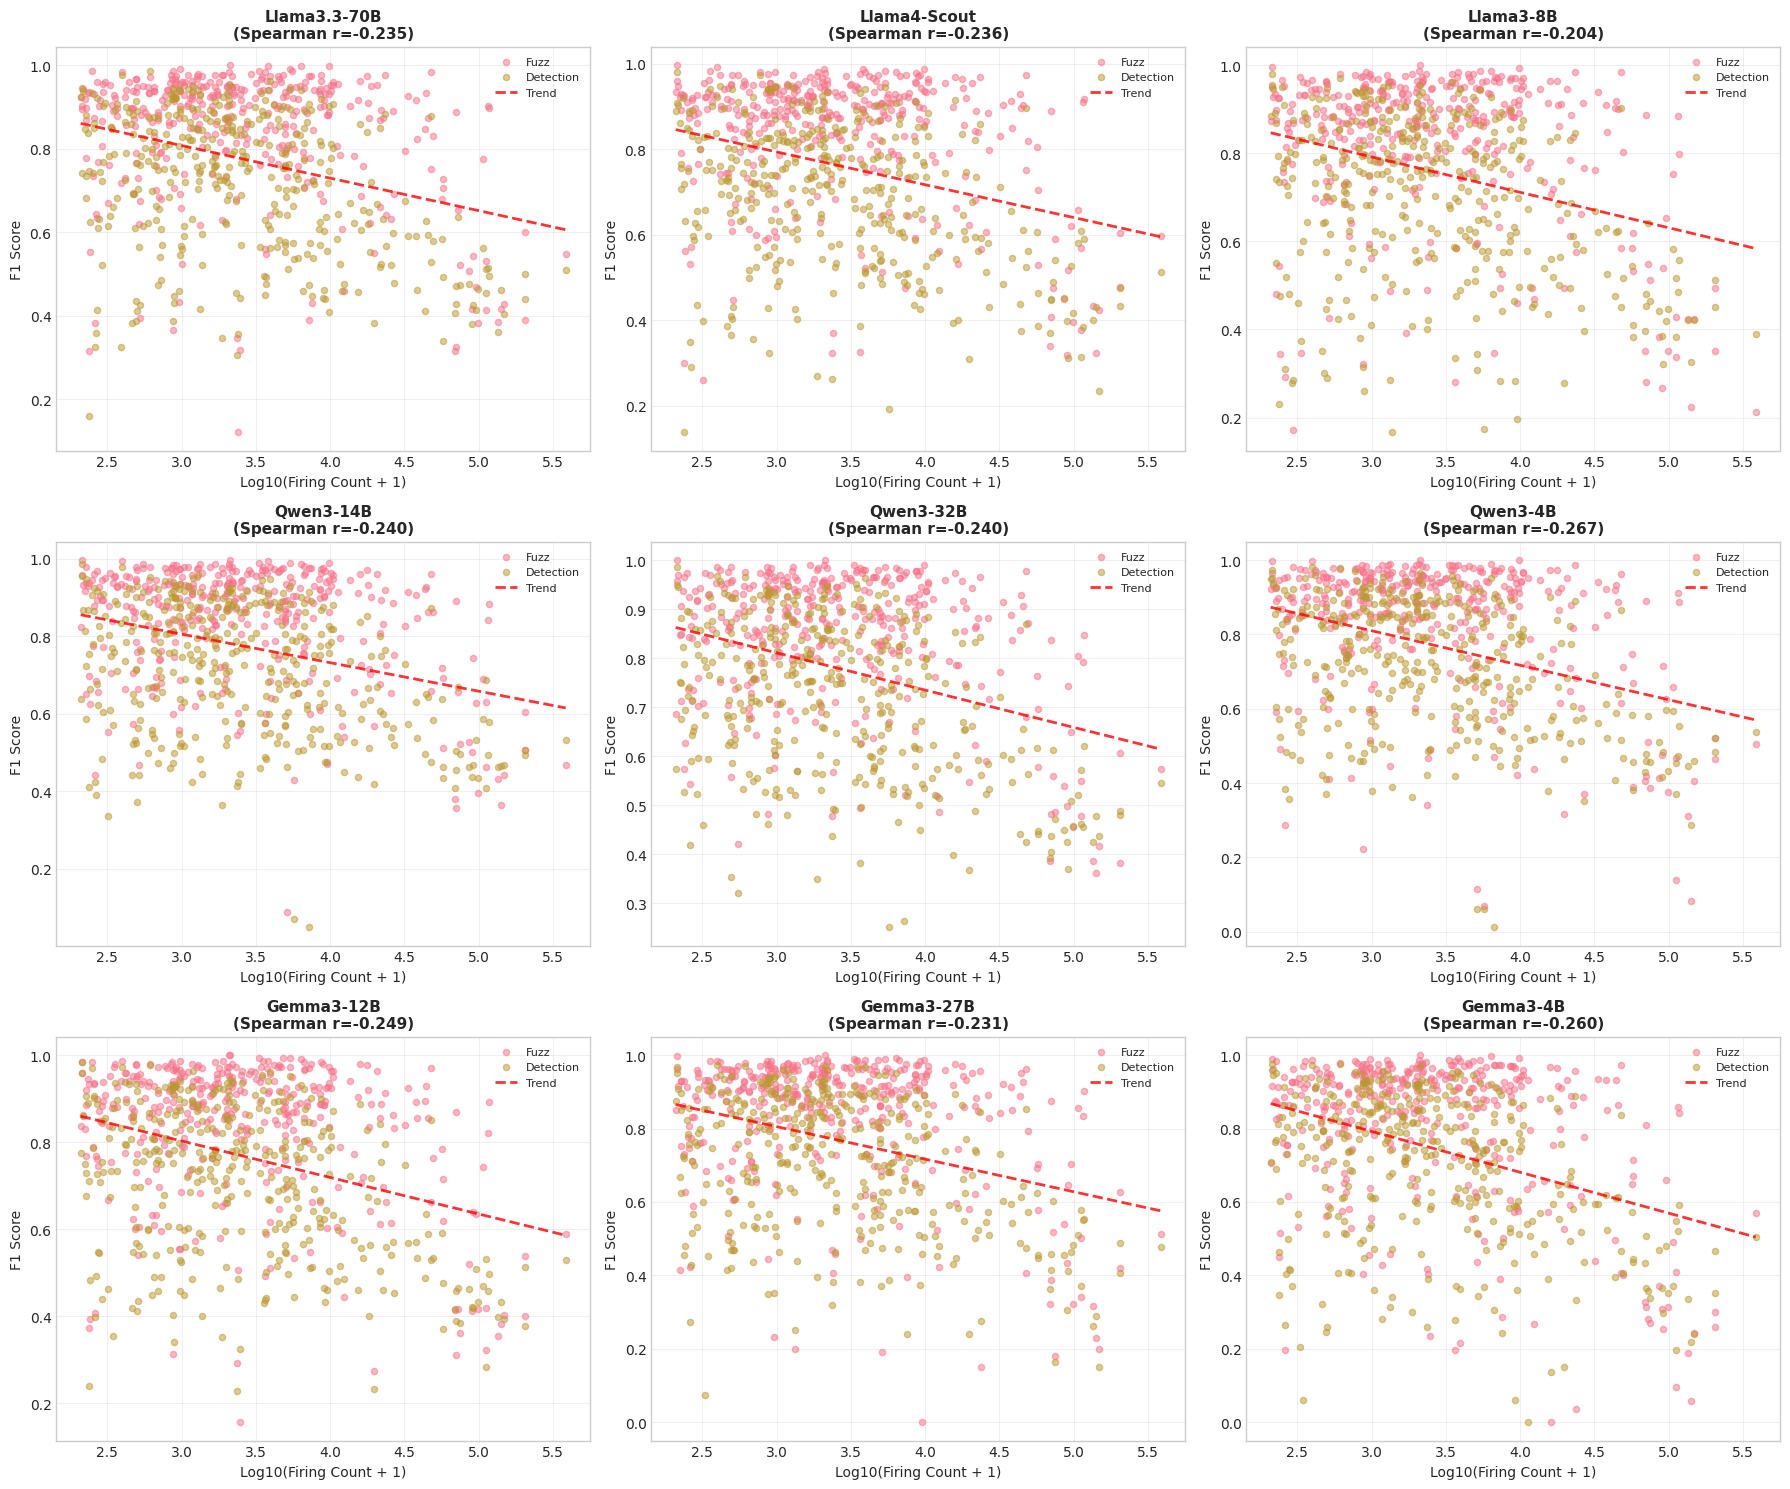


Plot saved as 'visualizations_dir/firing_rate_vs_f1_by_model.png'


In [7]:
# Create scatter plots showing the relationship
n_models = len(model_results)
n_cols = min(3, n_models)
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
if n_models == 1:
    axes = np.array([axes])
axes = axes.flatten()

for idx, (model_name, data) in enumerate(model_results.items()):
    ax = axes[idx]
    
    # Combine data from all score types for this model
    all_data = []
    for score_type in data['latent_df']['score_type'].unique():
        if f'per_latent_df_{score_type}' in data:
            df = data[f'per_latent_df_{score_type}'].copy()
            df['score_type'] = score_type
            all_data.append(df)
    
    if all_data:
        combined_df = pd.concat(all_data, ignore_index=True)
        
        # Scatter plot with color by score type
        for score_type in combined_df['score_type'].unique():
            subset = combined_df[combined_df['score_type'] == score_type]
            ax.scatter(subset['log_firing_count'], subset['f1_score'], 
                      alpha=0.5, s=20, label=score_type.capitalize())
        
        # Add trend line
        z = np.polyfit(combined_df['log_firing_count'], combined_df['f1_score'], 1)
        p = np.poly1d(z)
        x_trend = np.linspace(combined_df['log_firing_count'].min(), 
                            combined_df['log_firing_count'].max(), 100)
        ax.plot(x_trend, p(x_trend), "r--", alpha=0.8, linewidth=2, label='Trend')
        
        # Get correlation for this model
        model_corr = correlation_df[correlation_df['model'] == model_name]['spearman_r'].mean()
        
        ax.set_xlabel('Log10(Firing Count + 1)', fontsize=10)
        ax.set_ylabel('F1 Score', fontsize=10)
        ax.set_title(f'{model_name}\n(Spearman r={model_corr:.3f})', fontsize=11, fontweight='bold')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

# Hide unused subplots
for idx in range(len(model_results), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig(visualizations_dir / 'firing_rate_vs_f1_by_model.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nPlot saved as '{visualizations_dir / 'firing_rate_vs_f1_by_model.png'}'")

## 8. Analyze Performance on High vs Low Frequency Latents

Compare model performance when we split latents into high/low frequency groups using deciles (10% bins).

Firing Rate Deciles:
D1 (10%): 17
D2 (20%): 109
D3 (30%): 332
D4 (40%): 653
D5 (50%): 1091
D6 (60%): 1751
D7 (70%): 2940
D8 (80%): 5455
D9 (90%): 13833


F1 Score by Firing Rate Decile:
        mean_f1  n_latents  weight_contribution
decile                                         
D1          NaN        NaN                  NaN
D2          NaN        NaN                  NaN
D3       0.7684       31.0               0.0018
D4       0.7971       46.0               0.0050
D5       0.7954       49.0               0.0094
D6       0.8302       42.0               0.0130
D7       0.8099       47.0               0.0231
D8       0.7891       50.0               0.0470
D9       0.7585       55.0               0.0999
D10      0.6141       55.0               0.8009


/tmp/ipykernel_922677/3253808072.py:74: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_df = decile_df.pivot_table(


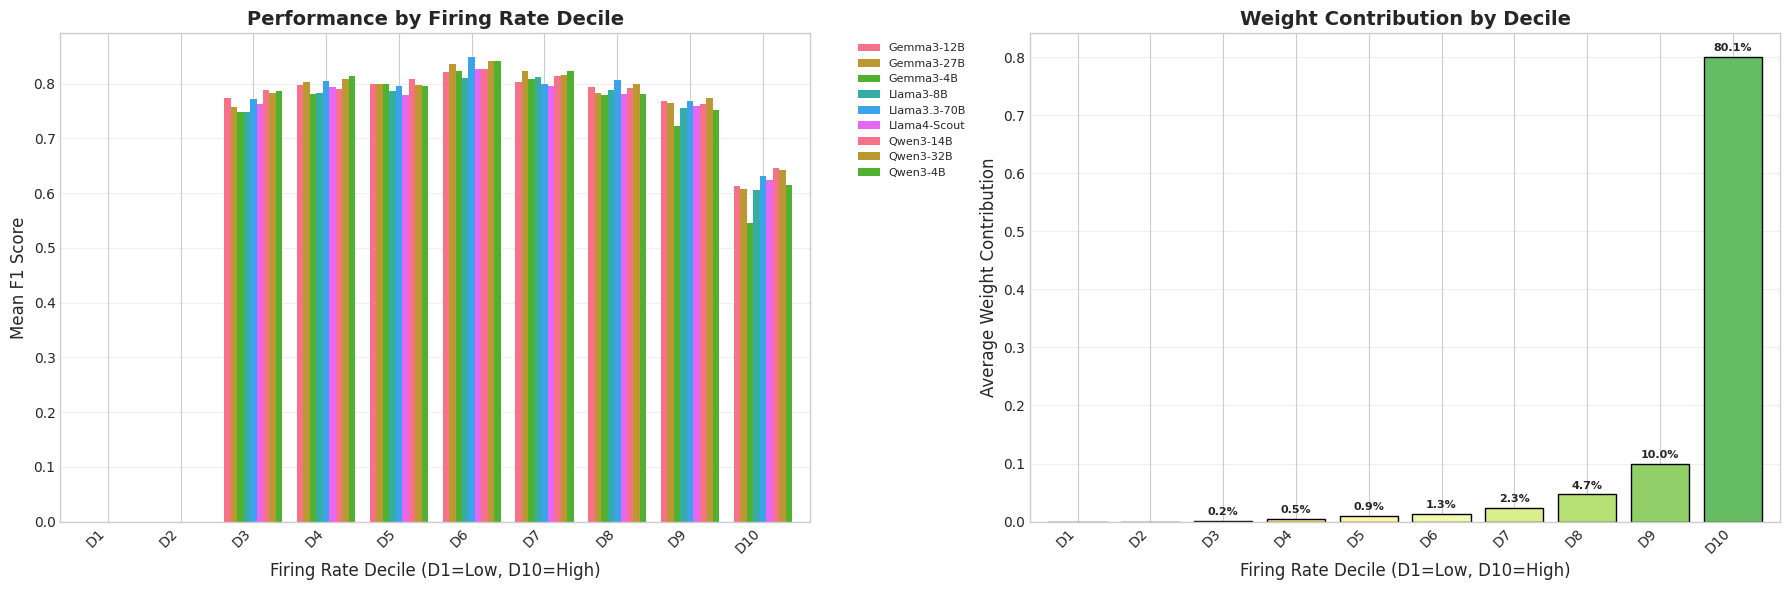


Plot saved as 'visualizations_dir/decile_analysis.png'


In [8]:
# Split latents into deciles by firing rate
first_model_name = list(model_results.keys())[0]
counts = model_results[first_model_name]['counts']

# Get all firing counts
all_firing_counts = []
for module in counts.keys():
    all_firing_counts.extend(counts[module].tolist())

# Compute deciles
decile_percentiles = np.arange(10, 100, 10)
decile_values = np.percentile(all_firing_counts, decile_percentiles)

print(f"Firing Rate Deciles:")
for i, (pct, val) in enumerate(zip(decile_percentiles, decile_values), 1):
    print(f"D{i} ({pct:.0f}%): {val:.0f}")

# For each model, compute F1 for different frequency groups
decile_results = []

for model_name, data in model_results.items():
    for score_type in data['latent_df']['score_type'].unique():
        if f'per_latent_df_{score_type}' not in data:
            continue
            
        per_latent_df = data[f'per_latent_df_{score_type}']
        
        # Assign deciles - use ordered categorical type to preserve order
        per_latent_df['decile'] = pd.cut(
            per_latent_df['firing_count'],
            bins=[0] + decile_values.tolist() + [np.inf],
            labels=[f'D{i}' for i in range(1, 11)],
            ordered=True
        )
        
        # Compute mean F1 for each decile
        for decile in [f'D{i}' for i in range(1, 11)]:
            decile_data = per_latent_df[per_latent_df['decile'] == decile]
            if len(decile_data) > 0:
                decile_results.append({
                    'model': model_name,
                    'score_type': score_type,
                    'decile': decile,
                    'mean_f1': decile_data['f1_score'].mean(),
                    'median_f1': decile_data['f1_score'].median(),
                    'n_latents': len(decile_data),
                    'weight_contribution': decile_data['firing_count'].sum() / per_latent_df['firing_count'].sum()
                })

decile_df = pd.DataFrame(decile_results)

# Convert decile to ordered categorical to ensure proper sorting
decile_df['decile'] = pd.Categorical(
    decile_df['decile'], 
    categories=[f'D{i}' for i in range(1, 11)], 
    ordered=True
)

print("\n\nF1 Score by Firing Rate Decile:")
print("="*80)
# Show summary statistics by decile
summary = decile_df.groupby('decile', observed=False).agg({
    'mean_f1': 'mean',
    'n_latents': 'mean',
    'weight_contribution': 'mean'
}).round(4)
print(summary)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Mean F1 by decile for each model
ax1 = axes[0]
pivot_df = decile_df.pivot_table(
    index='decile', 
    columns='model', 
    values='mean_f1', 
    aggfunc='mean'
)
# Ensure deciles are in order
pivot_df = pivot_df.reindex([f'D{i}' for i in range(1, 11)])
pivot_df.plot(kind='bar', ax=ax1, width=0.8)
ax1.set_xlabel('Firing Rate Decile (D1=Low, D10=High)', fontsize=12)
ax1.set_ylabel('Mean F1 Score', fontsize=12)
ax1.set_title('Performance by Firing Rate Decile', fontsize=14, fontweight='bold')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Plot 2: Weight contribution by decile
ax2 = axes[1]
weight_contrib = decile_df.groupby('decile', observed=False)['weight_contribution'].mean()
# Ensure deciles are in order
weight_contrib = weight_contrib.reindex([f'D{i}' for i in range(1, 11)])
# Create gradient from red (low) to green (high)
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(weight_contrib)))
weight_contrib.plot(kind='bar', ax=ax2, color=colors, width=0.8, edgecolor='black')
ax2.set_xlabel('Firing Rate Decile (D1=Low, D10=High)', fontsize=12)
ax2.set_ylabel('Average Weight Contribution', fontsize=12)
ax2.set_title('Weight Contribution by Decile', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')

# Add percentage labels
for i, v in enumerate(weight_contrib.values):
    if not np.isnan(v):
        ax2.text(i, v + 0.01, f'{v*100:.1f}%', ha='center', fontweight='bold', fontsize=8)

plt.tight_layout()
plt.savefig(visualizations_dir / 'decile_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nPlot saved as '{visualizations_dir / 'decile_analysis.png'}'")

## 9. Identify Which Models Benefit Most from Frequency Weighting


Models Ranked by Frequency Weighting Impact:
              unweighted_f1  weighted_f1    impact  impact_pct
model                                                         
Qwen3-14B          0.774309     0.618576 -0.155733  -20.094550
Qwen3-32B          0.778597     0.615285 -0.163312  -21.061110
Llama4-Scout       0.761184     0.596441 -0.164743  -21.792345
Llama3.3-70B       0.774316     0.602913 -0.171404  -22.237613
Gemma3-12B         0.767050     0.589483 -0.177567  -23.259125
Qwen3-4B           0.770682     0.587846 -0.182836  -23.653591
Gemma3-27B         0.767574     0.575337 -0.192237  -25.181973
Llama3-8B          0.757633     0.562556 -0.195077  -25.623363
Gemma3-4B          0.745047     0.522119 -0.222929  -29.802623


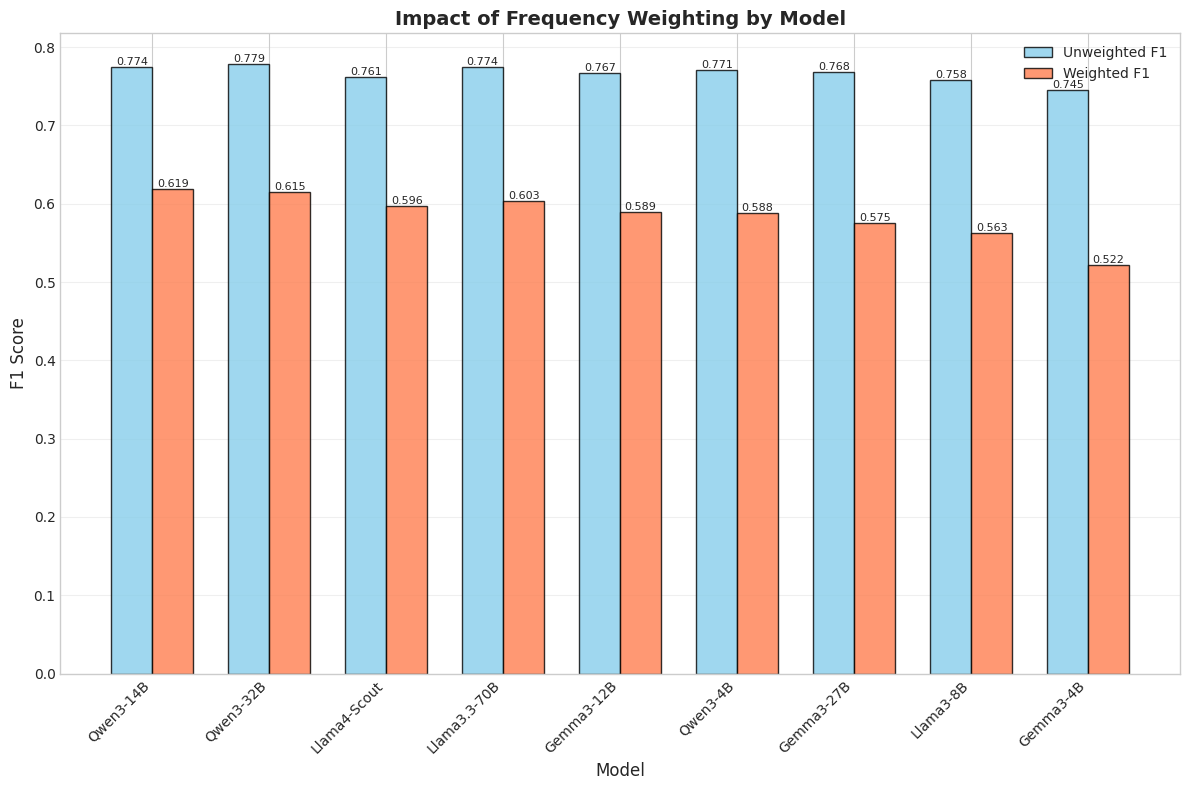


Plot saved as 'visualizations_dir/model_impact_ranking.png'


KEY INSIGHTS:

1. Model that BENEFITS MOST from frequency weighting: Qwen3-14B
   - Impact: +-0.1557
   - This model performs better on high-frequency latents

2. Model that SUFFERS MOST from frequency weighting: Gemma3-4B
   - Impact: -0.2229
   - This model performs better on low-frequency latents

3. Average impact across all models: -0.1806
   - Standard deviation: 0.0206


In [9]:
# Analyze which models gain or lose the most from frequency weighting
model_impact = comparison_df.groupby('model').agg({
    'unweighted_f1': 'mean',
    'weighted_f1': 'mean',
    'impact': 'mean',
    'impact_pct': 'mean'
}).sort_values('impact', ascending=False)

print("\nModels Ranked by Frequency Weighting Impact:")
print("="*80)
print(model_impact.to_string())

# Visualize
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

x = np.arange(len(model_impact))
width = 0.35

bars1 = ax.bar(x - width/2, model_impact['unweighted_f1'], width, 
               label='Unweighted F1', alpha=0.8, color='skyblue', edgecolor='black')
bars2 = ax.bar(x + width/2, model_impact['weighted_f1'], width, 
               label='Weighted F1', alpha=0.8, color='coral', edgecolor='black')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('Impact of Frequency Weighting by Model', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_impact.index, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(visualizations_dir / 'model_impact_ranking.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nPlot saved as '{visualizations_dir / 'model_impact_ranking.png'}'")

# Key insights
print("\n\n" + "="*80)
print("KEY INSIGHTS:")
print("="*80)

top_gainer = model_impact.index[0]
top_loser = model_impact.index[-1]

print(f"\n1. Model that BENEFITS MOST from frequency weighting: {top_gainer}")
print(f"   - Impact: +{model_impact.loc[top_gainer, 'impact']:.4f}")
print(f"   - This model performs better on high-frequency latents")

print(f"\n2. Model that SUFFERS MOST from frequency weighting: {top_loser}")
print(f"   - Impact: {model_impact.loc[top_loser, 'impact']:.4f}")
print(f"   - This model performs better on low-frequency latents")

print(f"\n3. Average impact across all models: {model_impact['impact'].mean():.4f}")
print(f"   - Standard deviation: {model_impact['impact'].std():.4f}")

## 10. Summary and Conclusions

In [10]:
print("="*80)
print("SUMMARY: Why Frequency Weighting Causes Such Large Differences")
print("="*80)

# Summary statistics - use nanmean to handle NaN values gracefully
avg_corr = correlation_df['spearman_r'].mean()

# Handle potential NaN values in decile calculations
d10_data = decile_df[decile_df['decile'] == 'D10']['weight_contribution']
d10_contrib = d10_data.mean() if len(d10_data) > 0 else 0.0

d1_f1_data = decile_df[decile_df['decile'] == 'D1']['mean_f1']
d1_f1 = d1_f1_data.mean() if len(d1_f1_data) > 0 else np.nan

d10_f1_data = decile_df[decile_df['decile'] == 'D10']['mean_f1']
d10_f1 = d10_f1_data.mean() if len(d10_f1_data) > 0 else np.nan

d10_f1_diff = d10_f1 - d1_f1 if not (np.isnan(d10_f1) or np.isnan(d1_f1)) else np.nan

print("\n1. CORRELATION BETWEEN FIRING RATE AND F1 SCORE:")
print(f"   - Average Spearman correlation: {avg_corr:.4f}")
if abs(avg_corr) > 0.3:
    direction = "higher" if avg_corr > 0 else "lower"
    print(f"   - High-frequency latents have {direction} F1 scores")
    print(f"   - This correlation AMPLIFIES differences when using frequency weighting")
elif abs(avg_corr) > 0.1:
    direction = "higher" if avg_corr > 0 else "lower"
    print(f"   - Weak positive correlation: high-frequency latents tend to have {direction} F1 scores")
else:
    print(f"   - Very weak correlation suggests minimal systematic differences")

print("\n2. WEIGHT DISTRIBUTION:")
print(f"   - Top 10% of latents (D10) contribute {d10_contrib*100:.1f}% of total weight")
# Also show cumulative for top 20% and 30%
d9_data = decile_df[decile_df['decile'] == 'D9']['weight_contribution']
d9_contrib = d9_data.mean() if len(d9_data) > 0 else 0.0
d8_data = decile_df[decile_df['decile'] == 'D8']['weight_contribution']
d8_contrib = d8_data.mean() if len(d8_data) > 0 else 0.0
top20_contrib = d10_contrib + d9_contrib
top30_contrib = d10_contrib + d9_contrib + d8_contrib
print(f"   - Top 20% of latents contribute {top20_contrib*100:.1f}% of total weight")
print(f"   - Top 30% of latents contribute {top30_contrib*100:.1f}% of total weight")
if d10_contrib > 0.25:
    print(f"   → The highest-firing latents DOMINATE the weighted average")
else:
    print(f"   → Weight is more evenly distributed across frequency ranges")

print("\n3. PERFORMANCE DIFFERENCES BY FREQUENCY GROUP:")
if not np.isnan(d10_f1):
    print(f"   - D10 (highest 10%) F1: {d10_f1:.4f}")
else:
    print(f"   - D10 (highest 10%) F1: N/A (no data)")
    
if not np.isnan(d1_f1):
    print(f"   - D1 (lowest 10%) F1: {d1_f1:.4f}")
else:
    print(f"   - D1 (lowest 10%) F1: N/A (no data)")
    
if not np.isnan(d10_f1_diff):
    print(f"   - Difference: {d10_f1_diff:.4f}")
    if abs(d10_f1_diff) > 0.1:
        direction = "better" if d10_f1_diff > 0 else "worse"
        print(f"   → Models perform SIGNIFICANTLY {direction} on high-frequency latents")
    elif abs(d10_f1_diff) > 0.05:
        direction = "better" if d10_f1_diff > 0 else "worse"
        print(f"   → Models perform moderately {direction} on high-frequency latents")
    else:
        print(f"   → Performance is similar across frequency ranges")
else:
    print(f"   - Difference: N/A (insufficient data)")

print("\n4. MODEL VARIABILITY:")
impact_std = model_impact['impact'].std()
impact_range = model_impact['impact'].max() - model_impact['impact'].min()
print(f"   - Standard deviation of impact: {impact_std:.4f}")
print(f"   - Range of impact: {impact_range:.4f}")
if impact_std > 0.02:
    print(f"   → Different models show VERY DIFFERENT patterns on high vs low frequency latents")
    print(f"   → Frequency weighting strongly differentiates model quality")
elif impact_std > 0.01:
    print(f"   → Models show moderately different patterns across frequency ranges")
    print(f"   → Frequency weighting reveals some meaningful differences")
else:
    print(f"   → Models show similar patterns across frequency ranges")

print("\n" + "="*80)
print("CONCLUSION:")
print("="*80)

# Build conclusion based on the data
conclusion_parts = []

# Part 1: Check if there's correlation and high-freq dominance
if abs(avg_corr) > 0.2 and d10_contrib > 0.25:
    conclusion_parts.append(
        "High-frequency latents (which dominate the weighted average) have systematically "
        "different F1 scores than low-frequency latents. This creates a natural "
        "amplification effect when weighting by frequency."
    )

# Part 2: Check if weight distribution is skewed
if d10_contrib > 0.3:
    conclusion_parts.append(
        f"The firing rate distribution is highly skewed: the top 10% of latents account "
        f"for {d10_contrib*100:.1f}% of all firings. This means a small number of "
        "high-frequency latents have outsized influence on the weighted score."
    )
elif d10_contrib > 0.2:
    conclusion_parts.append(
        f"The firing rate distribution is moderately skewed: the top 10% of latents account "
        f"for {d10_contrib*100:.1f}% of all firings. High-frequency latents have "
        "significant influence on the weighted score."
    )

# Part 3: Check for model variability
if impact_std > 0.02:
    conclusion_parts.append(
        "Different models show DISTINCT performance patterns on high vs low frequency latents. "
        "Without weighting, these differences are masked by treating all latents equally. "
        "With weighting, models that excel at high-frequency latents are properly rewarded."
    )
elif impact_std > 0.01:
    conclusion_parts.append(
        "Different models show varying performance on high vs low frequency latents. "
        "Frequency weighting reveals which models better handle the features that "
        "matter most in practice."
    )

# Part 4: Performance difference insight
if not np.isnan(d10_f1_diff) and abs(d10_f1_diff) > 0.1:
    direction = "easier" if d10_f1_diff > 0 else "harder"
    conclusion_parts.append(
        f"High-frequency latents are systematically {direction} to explain correctly "
        f"(difference of {abs(d10_f1_diff):.3f}). This systematic difference means "
        "that weighting by frequency changes which aspects of performance are emphasized."
    )

# Part 5: Practical implications
conclusion_parts.append(
    "From a practical perspective, frequency-weighted F1 is more meaningful because it "
    "emphasizes performance on the latents that activate most often in real usage. "
    "Unweighted F1 treats rare and common latents equally, which may not reflect "
    "real-world importance."
)

# Print conclusion with proper formatting
for i, part in enumerate(conclusion_parts, 1):
    print(f"\n{i}. {part}")

print("\n" + "="*80)

SUMMARY: Why Frequency Weighting Causes Such Large Differences

1. CORRELATION BETWEEN FIRING RATE AND F1 SCORE:
   - Average Spearman correlation: -0.2402
   - Weak positive correlation: high-frequency latents tend to have lower F1 scores

2. WEIGHT DISTRIBUTION:
   - Top 10% of latents (D10) contribute 80.1% of total weight
   - Top 20% of latents contribute 90.1% of total weight
   - Top 30% of latents contribute 94.8% of total weight
   → The highest-firing latents DOMINATE the weighted average

3. PERFORMANCE DIFFERENCES BY FREQUENCY GROUP:
   - D10 (highest 10%) F1: 0.6141
   - D1 (lowest 10%) F1: N/A (no data)
   - Difference: N/A (insufficient data)

4. MODEL VARIABILITY:
   - Standard deviation of impact: 0.0206
   - Range of impact: 0.0672
   → Different models show VERY DIFFERENT patterns on high vs low frequency latents
   → Frequency weighting strongly differentiates model quality

CONCLUSION:

1. High-frequency latents (which dominate the weighted average) have systematic